# Notebook 1 — Data Loading, EDA & Preprocessing
## Derm Fairness Project · Fitzpatrick17k

**Research question:** For a binary skin-lesion triage task (malignant vs. benign/non-malignant),
do underrepresented skin-tone groups experience worse malignant-case recall,
and do rebalancing and targeted fine-tuning improve worst-group performance?

---
### MIMIC portability note
Every section here has a direct MIMIC equivalent:
- `load_fitzpatrick()` → `load_mimic_notes()`
- `skin_tone` group column → `ethnicity` / `language` group column
- `binary_label` (malignant=1) → `hospital_expire_flag` (mortality=1)
- Image tensor pipeline → ClinicalBERT tokenizer pipeline

## 0 · Install & imports

In [ ]:
#install pandas numpy matplotlib seaborn scikit-learn torch torchvision pillow tqdm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)

## 1 · Download Fitzpatrick17k

The metadata CSV is hosted on GitHub (no sign-in needed).  
Images are downloaded lazily in Notebook 2 via URL column.

In [ ]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

META_URL = 'https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/main/fitzpatrick17k.csv'
META_PATH = DATA_DIR / 'fitzpatrick17k.csv'

if not META_PATH.exists():
    import urllib.request
    urllib.request.urlretrieve(META_URL, META_PATH)
    print('Downloaded')
else:
    print('already present')

Downloaded metadata CSV


## 2 · Load & inspect raw metadata

In [4]:
df_raw = pd.read_csv(META_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (16577, 9)


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [5]:
print(df_raw.dtypes)
print('\nNull counts:')
print(df_raw.isnull().sum())

md5hash                  object
fitzpatrick_scale         int64
fitzpatrick_centaur       int64
label                    object
nine_partition_label     object
three_partition_label    object
qc                       object
url                      object
url_alphanum             object
dtype: object

Null counts:
md5hash                      0
fitzpatrick_scale            0
fitzpatrick_centaur          0
label                        0
nine_partition_label         0
three_partition_label        0
qc                       16073
url                         41
url_alphanum                 0
dtype: int64


In [ ]:
print('Fitzpatrick scale values:', sorted(df_raw['fitzpatrick_scale'].dropna().unique()))
print('\nLabel (nine_partition_label) sample:')
print(df_raw['nine_partition_label'].value_counts())

Fitzpatrick scale values: [np.int64(-1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Label (nine_partition_label) sample:
nine_partition_label
inflammatory                    10886
malignant epidermal              1352
genodermatoses                   1194
benign dermal                    1067
benign epidermal                  931
malignant melanoma                573
benign melanocyte                 236
malignant cutaneous lymphoma      182
malignant dermal                  156
Name: count, dtype: int64


## 3 · Feature engineering

### 3a · Binary label — malignant vs. benign
Fitzpatrick17k uses a `three_partition_label` column: `malignant`, `non-neoplastic`, `benign`.  
We map this to a single binary target.

In [8]:
print('three_partition_label counts:')
print(df_raw['three_partition_label'].value_counts())

three_partition_label counts:
three_partition_label
non-neoplastic    12080
malignant          2263
benign             2234
Name: count, dtype: int64


In [9]:
def make_binary_label(val):
    """1 = malignant (the 'positive' class we care about missing), 0 = otherwise."""
    if pd.isna(val):
        return np.nan
    return 1 if str(val).strip().lower() == 'malignant' else 0

df_raw['binary_label'] = df_raw['three_partition_label'].apply(make_binary_label)
print(df_raw['binary_label'].value_counts())

binary_label
0    14314
1     2263
Name: count, dtype: int64


### 3b · Skin tone group
Fitzpatrick scale 1-6:  
- **Light** = FST 1–2  
- **Medium** = FST 3–4  
- **Dark** = FST 5–6  

This is the `group` column used everywhere in fairness metrics.

> **MIMIC equivalent:** replace with `ethnicity_group` (White / Black / Hispanic / Asian) or `language_group` (English / non-English)

In [13]:
def map_skin_tone_group(fst):
    try:
        fst = int(fst)
    except (ValueError, TypeError):
        return np.nan
    if fst in (1, 2):
        return 'light'
    elif fst in (3, 4):
        return 'medium'
    elif fst in (5, 6):
        return 'dark'
    return np.nan

df_raw['group'] = df_raw['fitzpatrick_scale'].apply(map_skin_tone_group)
print(df_raw['group'].value_counts())

group
light     7755
medium    6089
dark      2168
Name: count, dtype: int64


## 4 · Clean & filter

In [14]:
df = df_raw.dropna(subset=['binary_label', 'group', 'url']).copy()
df = df.reset_index(drop=True)
print(f'Clean dataset shape: {df.shape}')

Clean dataset shape: (15974, 11)


## 5 · Exploratory Data Analysis

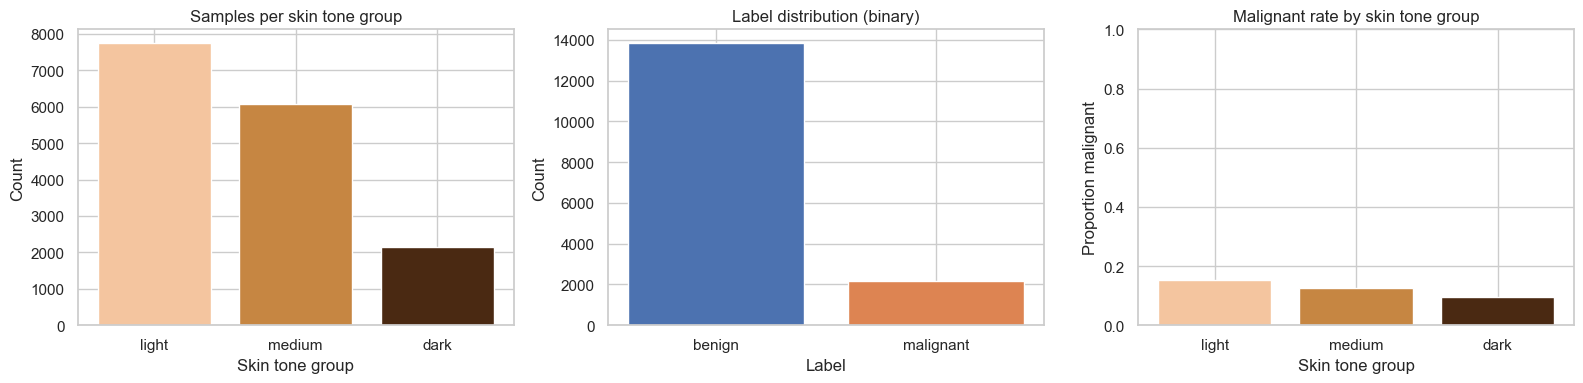

Saved to data/eda_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

group_counts = df['group'].value_counts()
axes[0].bar(group_counts.index, group_counts.values, color=['#f4c59f','#c68642','#4a2912'])
axes[0].set_title('Samples per skin tone group')
axes[0].set_xlabel('Skin tone group')
axes[0].set_ylabel('Count')

label_counts = df['binary_label'].map({0:'benign', 1:'malignant'}).value_counts()
axes[1].bar(label_counts.index, label_counts.values, color=['#4c72b0','#dd8452'])
axes[1].set_title('Label distribution (binary)')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

malignant_rate = df.groupby('group')['binary_label'].mean().reindex(['light','medium','dark'])
axes[2].bar(malignant_rate.index, malignant_rate.values, color=['#f4c59f','#c68642','#4a2912'])
axes[2].set_title('Malignant rate by skin tone group')
axes[2].set_xlabel('Skin tone group')
axes[2].set_ylabel('Proportion malignant')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/eda_overview.png')

In [ ]:
crosstab = pd.crosstab(df['group'], df['binary_label'].map({0:'benign', 1:'malignant'}), margins=True)
print(crosstab)

binary_label  benign  malignant    All
group                                 
dark            1952        206   2158
light           6544       1195   7739
medium          5320        757   6077
All            13816       2158  15974


## 6 · Train / Val / Test split

Stratify on **group × label** so each split has the same subgroup × class proportions.  
This is critical — a naive split can accidentally put all dark-skin malignant cases in test.

In [ ]:
from sklearn.model_selection import train_test_split

df['strat_key'] = df['group'] + '_' + df['binary_label'].astype(str)
valid_keys = df['strat_key'].value_counts()
valid_keys = valid_keys[valid_keys >= 4].index
df = df[df['strat_key'].isin(valid_keys)].copy()

# 70% train, 15% val, 15% test
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df['strat_key'], random_state=SEED)
df_val, df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['strat_key'], random_state=SEED)

print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print('\nTest set group × label distribution:')
print(pd.crosstab(df_test['group'], df_test['binary_label']))

Train: 11181 | Val: 2396 | Test: 2397

Test set group × label distribution:
binary_label    0    1
group                 
dark          293   31
light         982  180
medium        798  113


## 7 · Save processed splits

In [18]:
df_train.to_csv('data/train.csv', index=False)
df_val.to_csv('data/val.csv', index=False)
df_test.to_csv('data/test.csv', index=False)
print('Splits saved to data/')

Splits saved to data/


---
### ✅ Notebook 1 complete
**Outputs:** `data/train.csv`, `data/val.csv`, `data/test.csv`, `data/eda_overview.png`  
**Next:** Notebook 2 — Model training & all 5 mitigations